In [70]:
import pandas as pd
import numpy as np
import requests
import os

#pd.set_option('display.max_columns', None)


In [71]:
print(os.getcwd())

/Users/alessandrogalleani/code/alessandrog403/PowerForecast


Country            len     data from                      to

Bulgaria           65736   2016-10-01 00:00:00    -> 2024-03-31 23:00:00
Serbia             64272   2016-12-01 00:00:00       2024-03-31 23:00:00	+ nan
Croatia            56976   2017-10-01 00:00:00       2024-03-31 23:00:00
North Macedonia     8064   2023-05-01 00:00:00       2024-03-31 23:00:00. - > I WILL KILL
Ireland            68592   2015-01-01 00:00:00       2024-03-31 23:00:00. + nan. + nan

Other              81072   2015-01-01 00:00:00.      2024-03-31 23:00:00

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pivot_table.html

In [ ]:
from power_forecast.logic.get_data.download_api import create_dataframe_base, align_start_to_column

In [74]:

df = create_dataframe_base('raw_data/all_countries.csv')
print(df.shape)


(81072, 29)


In [80]:
df

,AUT,BEL,BGR,CHE,CZE,DEU,DNK,ESP,EST,FIN,...,MKD,NLD,NOR,POL,PRT,ROU,SRB,SVK,SVN,SWE
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00+00:00,17.93,34.94,NaN,43.43,24.20,17.93,18.29,48.10,23.37,23.37,...,NaN,34.94,27.36,17.18,48.10,44.17,NaN,24.20,23.25,23.37
2015-01-01 01:00:00+00:00,15.17,32.19,NaN,38.08,22.06,15.17,16.04,47.33,19.33,19.33,...,NaN,32.19,27.24,17.38,47.33,39.17,NaN,22.06,22.20,19.33
2015-01-01 02:00:00+00:00,16.38,28.05,NaN,35.47,20.27,16.38,14.60,42.27,17.66,17.66,...,NaN,28.05,27.16,17.40,42.27,26.93,NaN,20.27,19.56,17.66
2015-01-01 03:00:00+00:00,17.38,28.04,NaN,30.83,19.17,17.38,14.95,38.41,17.53,17.53,...,NaN,28.04,27.15,18.60,38.41,20.94,NaN,19.17,18.88,17.53
2015-01-01 04:00:00+00:00,16.38,34.26,NaN,28.26,17.90,16.38,14.50,35.72,18.07,18.07,...,NaN,34.26,27.30,19.30,35.72,18.52,NaN,17.90,18.39,18.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-31 19:00:00+00:00,66.17,47.01,65.81,74.52,68.37,70.00,70.00,3.20,50.09,50.09,...,65.84,65.20,57.09,69.99,3.20,65.81,60.05,67.09,63.43,50.09
2024-03-31 20:00:00+00:00,61.25,43.70,60.90,67.31,63.26,64.51,64.51,3.20,46.28,46.28,...,65.37,60.55,55.85,72.43,3.20,60.90,61.00,62.10,58.74,46.28
2024-03-31 21:00:00+00:00,44.99,50.29,48.07,62.86,51.29,54.90,54.90,1.63,43.98,43.98,...,59.99,54.90,53.50,75.27,1.63,48.07,59.98,49.03,46.61,43.98


In [136]:
df_aligned = align_start_to_column(df, column='HRV', apply=True)
df_aligned.shape

New start: 2017-10-01 00:00:00+00:00 | Dropped 24096 rows | 56976 remaining


(56976, 29)

In [ ]:
# from matplotlib import pyplot as plt

# for feature in df.select_dtypes(include='number').columns:  # ← add .columns
    
#     fig, ax = plt.subplots(1, 2, figsize=(12, 3))  # ← plt.subplots not df.subplots
#     fig.suptitle(feature)
    
#     df[[feature]].boxplot(ax=ax[0])
#     df[[feature]].hist(ax=ax[1], bins=50)
    
#     plt.tight_layout()
#     plt.show()

In [137]:
df_aligned.describe()

,AUT,BEL,BGR,CHE,CZE,DEU,DNK,ESP,EST,FIN,...,MKD,NLD,NOR,POL,PRT,ROU,SRB,SVK,SVN,SWE
count,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,...,8064.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000
mean,95.018882,92.799807,95.466648,102.283487,91.574881,87.552664,80.338967,81.698697,81.167134,65.844656,...,93.148641,91.495600,57.448520,84.232631,82.014018,99.471928,101.797531,96.108619,101.817866,55.575055
std,102.181968,95.790414,97.121643,103.633583,96.379402,98.261122,90.991573,62.883676,86.046742,78.241071,...,33.469345,93.723884,54.039208,58.407165,62.720154,102.420787,101.320940,101.956974,102.809692,60.575689
min,-500.000000,-500.000000,-1.800000,-142.880000,-68.540000,-500.000000,-288.140000,0.000000,-60.040000,-500.000000,...,0.000000,-500.000000,-32.710000,-13.810000,0.000000,-23.180000,0.000000,-65.000000,-500.000000,-60.040000
25%,36.970000,37.930000,37.240000,41.040000,37.000000,34.880000,32.990000,42.680000,36.310000,28.510000,...,73.487500,38.040000,30.010000,47.097500,43.000000,40.100000,42.330000,37.830000,42.010000,26.577500
50%,55.920000,58.265000,58.075000,61.970000,56.040000,52.420000,49.550000,60.240000,53.000000,44.620000,...,94.000000,55.960000,43.160000,63.870000,60.530000,62.630000,63.970000,58.865000,63.295000,40.380000
75%,111.022500,106.910000,114.820000,118.910000,106.052500,100.612500,92.062500,103.590000,96.072500,69.762500,...,112.150000,106.520000,69.080000,105.510000,103.800000,117.270000,117.770000,110.000000,118.160000,58.930000
max,908.900000,871.000000,936.330000,871.610000,871.000000,1047.110000,871.000000,700.000000,4000.000000,1896.000000,...,273.600000,871.000000,587.630000,771.000000,651.000000,964.210000,889.520000,900.230000,879.290000,652.670000


In [139]:
limit_low  = -350
limit_high = 2000

In [140]:


for col in df_aligned.columns:
    n_high = (df_aligned[col] > limit_high).sum()
    n_low  = (df_aligned[col] < limit_low).sum()
    total  = n_high + n_low
    if total > 0:  # only print if there are outliers
        print(f"{col}: {n_low} below {limit_low} | {n_high} above {limit_high} | total: {total}")

AUT: 1 below -350 | 0 above 2000 | total: 1
BEL: 2 below -350 | 0 above 2000 | total: 2
DEU: 2 below -350 | 0 above 2000 | total: 2
EST: 0 below -350 | 1 above 2000 | total: 1
FIN: 10 below -350 | 0 above 2000 | total: 10
FRA: 0 below -350 | 2 above 2000 | total: 2
HRV: 1 below -350 | 0 above 2000 | total: 1
HUN: 1 below -350 | 0 above 2000 | total: 1
LTU: 0 below -350 | 2 above 2000 | total: 2
LUX: 2 below -350 | 0 above 2000 | total: 2
LVA: 0 below -350 | 2 above 2000 | total: 2
NLD: 5 below -350 | 0 above 2000 | total: 5
SVN: 1 below -350 | 0 above 2000 | total: 1


In [141]:


total_low  = (df < limit_low).sum().sum()
total_high = (df > limit_high).sum().sum()

print(f"Below {limit_low}:  {total_low} values")
print(f"Above {limit_high}: {total_high} values")
print(f"Total to replace:   {total_low + total_high} / {df.size} ({(total_low + total_high) / df.size * 100:.4f}%)")

Below -350:  25 values
Above 2000: 8 values
Total to replace:   33 / 2351088 (0.0014%)


In [142]:
limit_low  = -350
limit_high = 3200

for col in df.columns:
    mask = (df[col] < limit_low) | (df[col] > limit_high)
    if mask.any():
        outlier_dates = df[mask][col]
        print(f"\n{col} — {len(outlier_dates)} outliers:")
        print(outlier_dates.to_string())  # prints timestamp + value



AUT — 1 outliers:
datetime_utc
2023-07-02 12:00:00+00:00   -500.0

BEL — 2 outliers:
datetime_utc
2019-06-08 00:00:00+00:00   -500.0
2019-06-08 03:00:00+00:00   -500.0

DEU — 2 outliers:
datetime_utc
2023-07-02 12:00:00+00:00   -500.0
2023-07-02 13:00:00+00:00   -399.0

EST — 1 outliers:
datetime_utc
2022-08-17 15:00:00+00:00    4000.0

FIN — 10 outliers:
datetime_utc
2023-11-24 13:00:00+00:00   -500.0
2023-11-24 14:00:00+00:00   -500.0
2023-11-24 15:00:00+00:00   -500.0
2023-11-24 16:00:00+00:00   -500.0
2023-11-24 17:00:00+00:00   -500.0
2023-11-24 18:00:00+00:00   -500.0
2023-11-24 19:00:00+00:00   -500.0
2023-11-24 20:00:00+00:00   -500.0
2023-11-24 21:00:00+00:00   -500.0
2023-11-24 22:00:00+00:00   -500.0

HRV — 1 outliers:
datetime_utc
2023-07-02 12:00:00+00:00   -500.0

HUN — 1 outliers:
datetime_utc
2023-07-02 12:00:00+00:00   -500.0

LTU — 1 outliers:
datetime_utc
2022-08-17 15:00:00+00:00    4000.0

LUX — 2 outliers:
datetime_utc
2023-07-02 12:00:00+00:00   -500.0
2023-07-0

In [ ]:
def replace_outliers_with_interpolation(df, limit_low, limit_high):
    """
    Replace values outside [limit_low, limit_high] with NaN,
    then interpolate all NaNs
    """

    # Replace outliers with NaN
    df_clean = df.copy()
    df_clean[df_clean < limit_low] = float('nan')
    df_clean[df_clean > limit_high] = float('nan')

    # Interpolate ALL NaNs (pre-existing + new outliers)
    df_interpolated = df_clean.interpolate(method='time')

    return df_interpolated




In [132]:
df_clean = replace_outliers_with_interpolation(df, limit_low=-350, limit_high=3200)

In [133]:
df_clean.describe()

,AUT,BEL,BGR,CHE,CZE,DEU,DNK,ESP,EST,FIN,...,MKD,NLD,NOR,POL,PRT,ROU,SRB,SVK,SVN,SWE
count,81072.000000,81072.000000,65736.000000,81072.000000,81072.000000,81072.000000,81072.000000,81072.000000,81072.000000,81072.000000,...,8064.000000,81072.000000,81072.000000,81072.000000,81072.000000,81072.000000,64272.000000,81072.000000,81072.000000,81072.000000
mean,76.160979,77.295127,88.303996,83.664515,74.222359,70.915316,64.517878,71.218085,66.631765,55.743863,...,93.148641,75.177159,47.648969,70.025306,71.438546,81.358266,96.059328,77.892459,83.841292,47.138944
std,90.723199,84.566833,93.289934,91.894182,85.430286,86.549156,80.280396,55.660517,74.583579,67.512127,...,33.469345,82.654866,47.924336,54.053029,55.565892,90.799855,97.001500,90.375385,91.010085,52.745710
min,-140.000000,-350.000000,-1.800000,-142.880000,-68.540000,-266.920000,-288.140000,0.000000,-60.040000,-60.040000,...,0.000000,-252.920000,-32.710000,-13.810000,0.000000,-23.180000,0.000000,-65.000000,-83.810000,-60.040000
25%,30.200000,33.840000,34.560000,35.490000,30.837500,29.210000,25.870000,40.880000,29.900000,26.030000,...,73.487500,33.260000,23.900000,37.570000,41.000000,33.940000,41.670000,31.400000,36.970000,23.530000
50%,43.490000,48.265000,53.030000,50.055000,44.360000,41.920000,38.610000,53.550000,42.870000,37.970000,...,94.000000,45.480000,33.960000,50.460000,53.690000,50.210000,60.060000,46.000000,52.000000,33.740000
75%,81.020000,82.470000,104.460000,86.010000,80.512500,75.752500,67.070000,77.502500,71.190000,56.280000,...,112.150000,79.400000,52.560000,84.972500,77.930000,87.482500,107.595000,84.630000,88.092500,49.840000
max,908.900000,871.000000,3119.840000,871.610000,871.000000,1047.110000,871.000000,700.000000,1896.000000,1896.000000,...,273.600000,871.000000,587.630000,771.000000,651.000000,964.210000,889.520000,900.230000,879.290000,652.670000


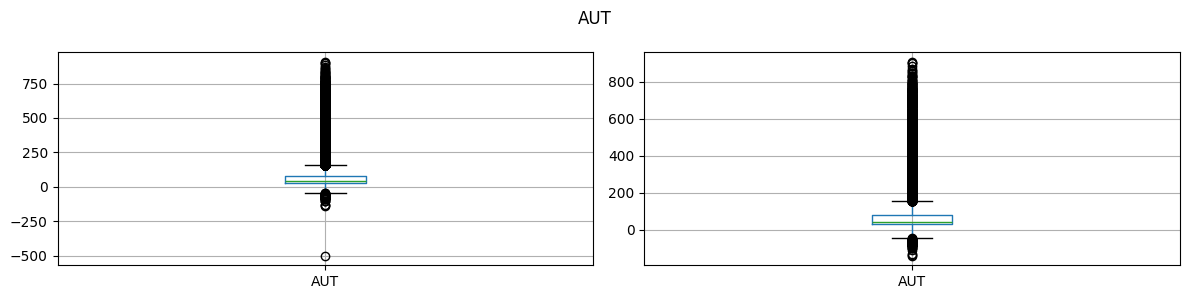

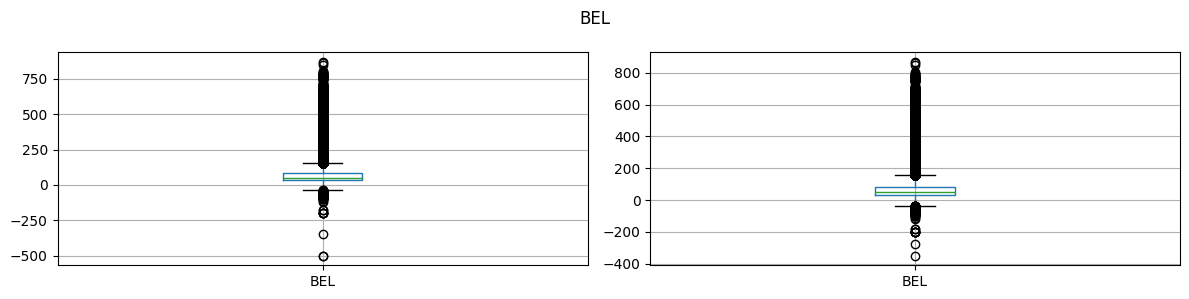

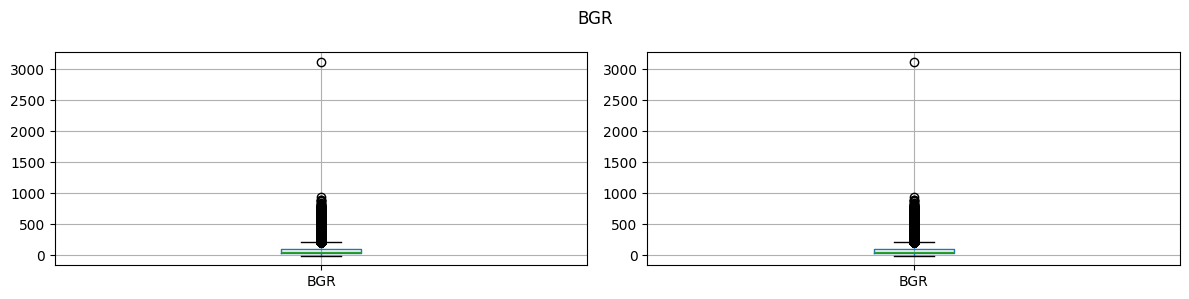

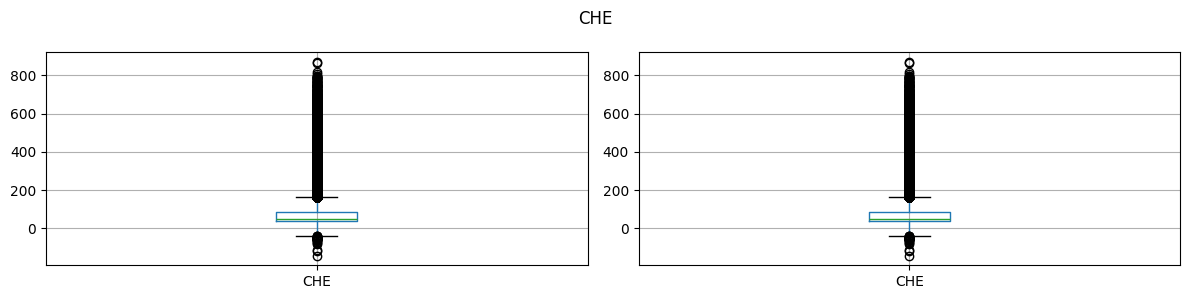

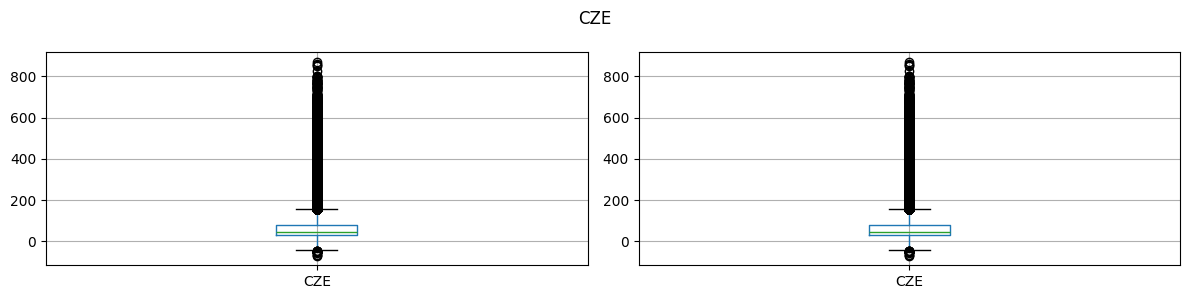

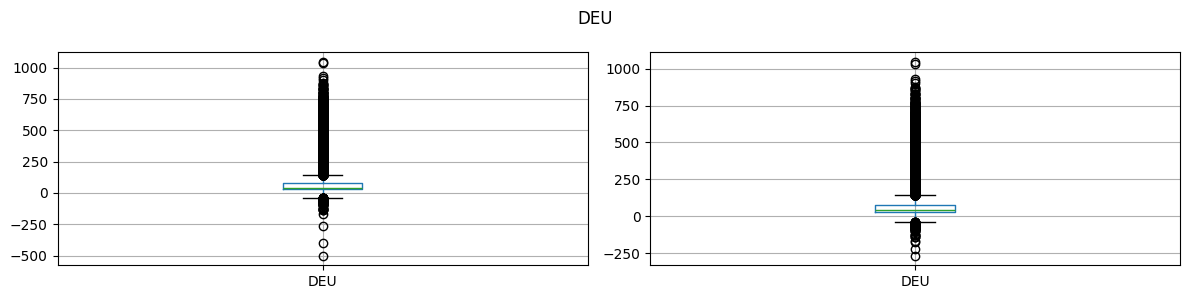

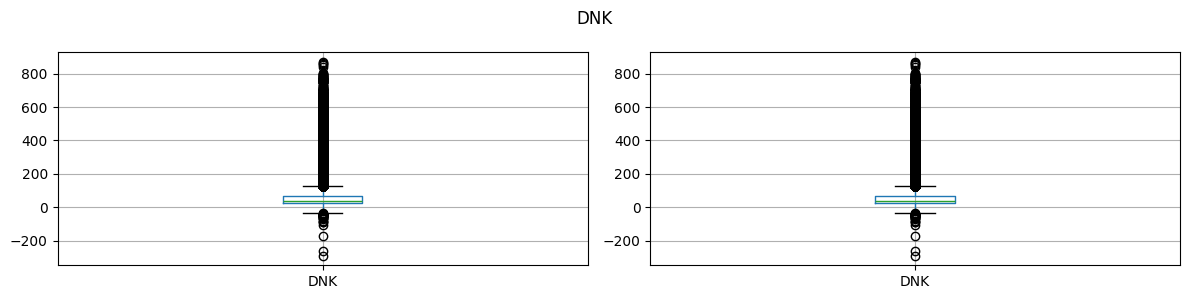

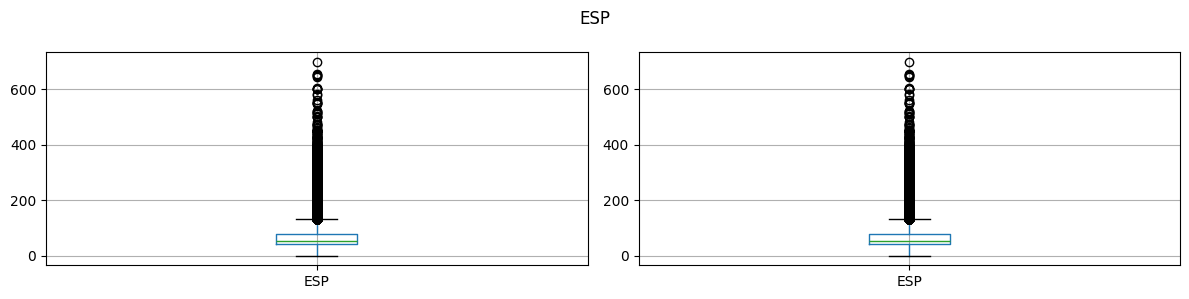

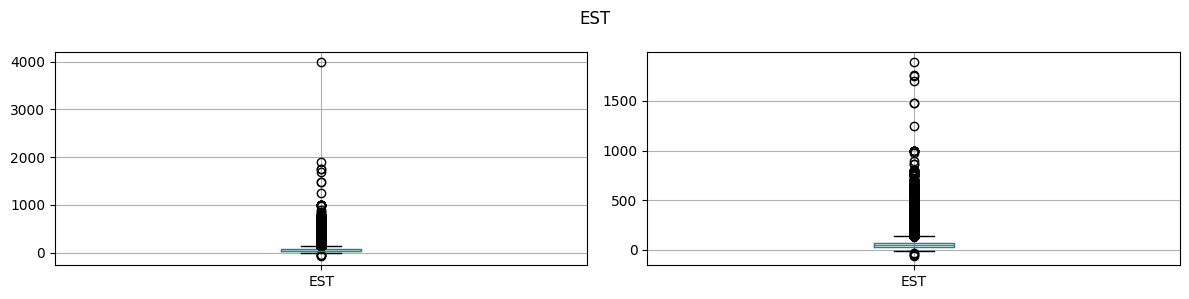

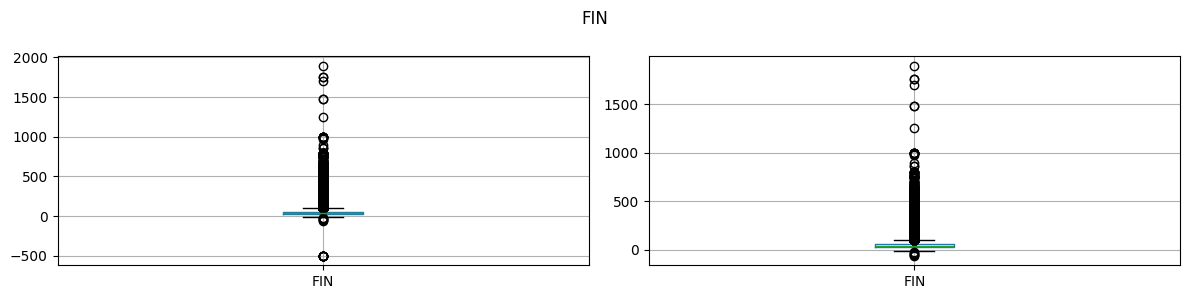

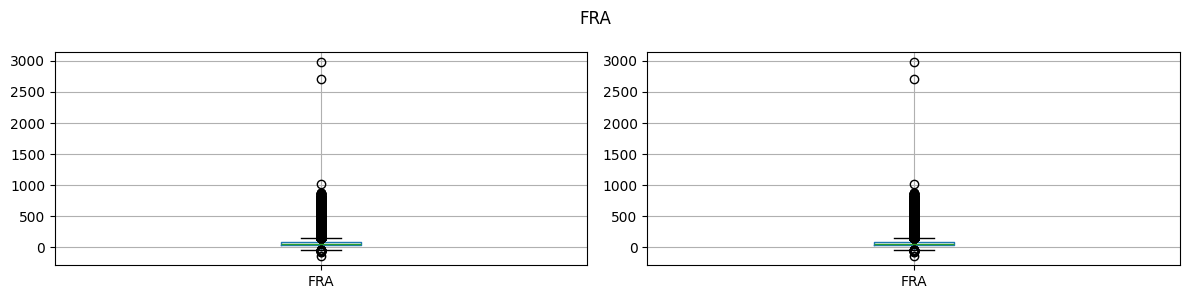

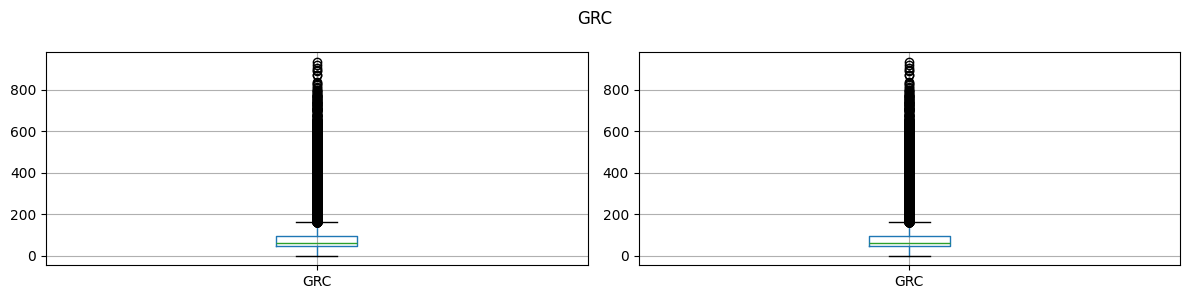

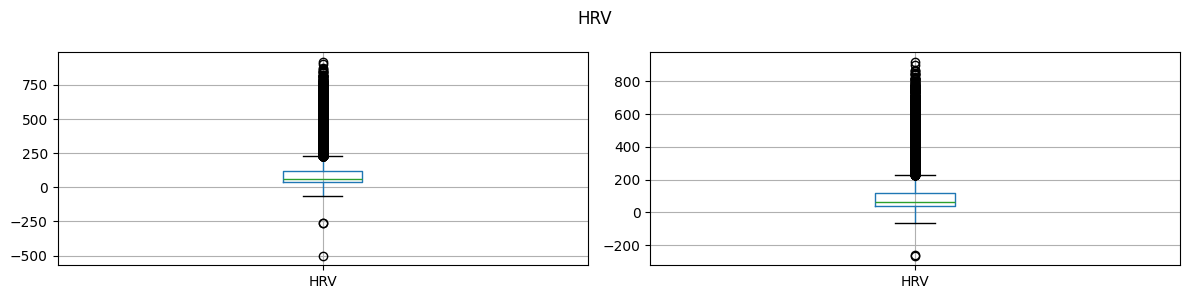

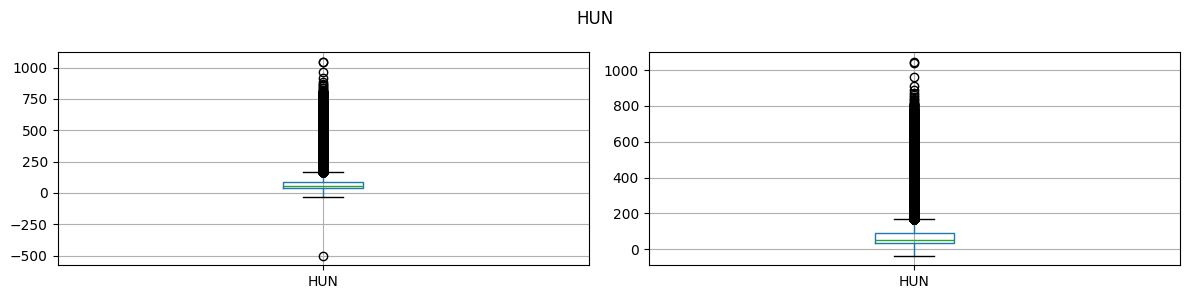

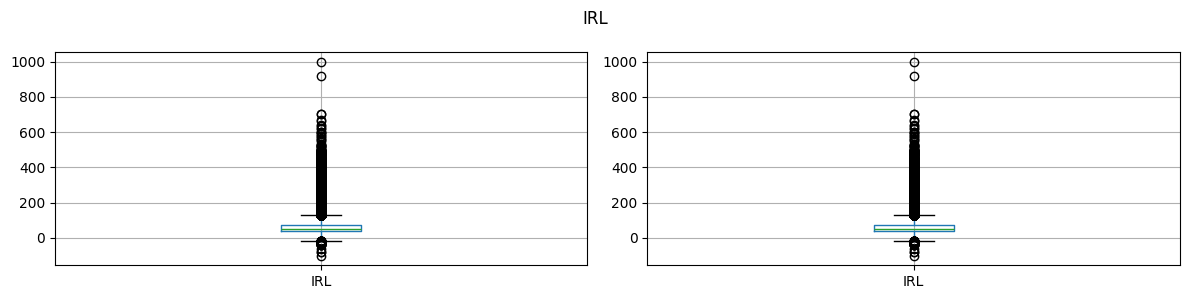

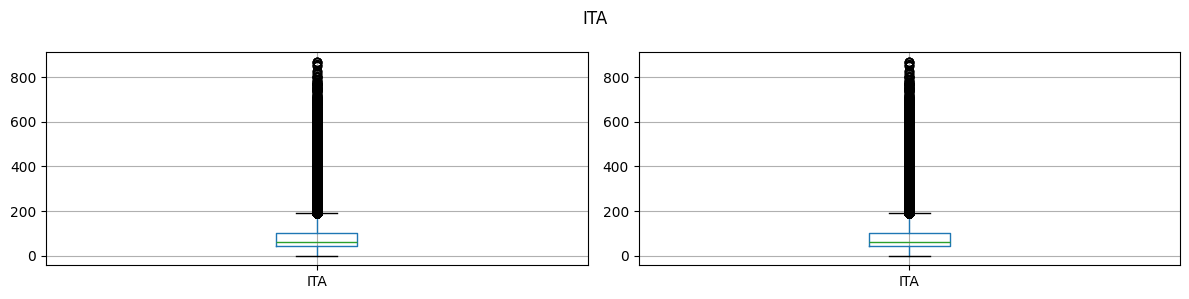

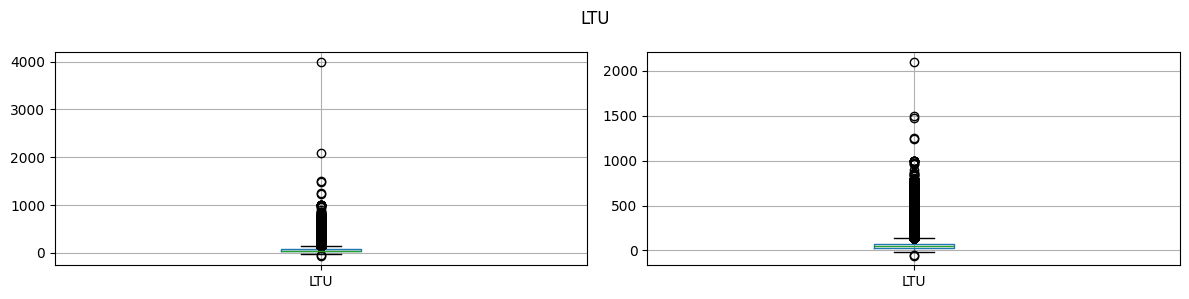

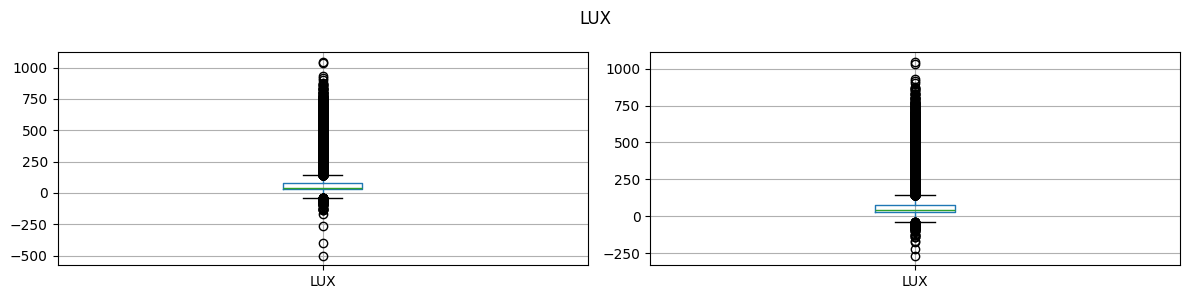

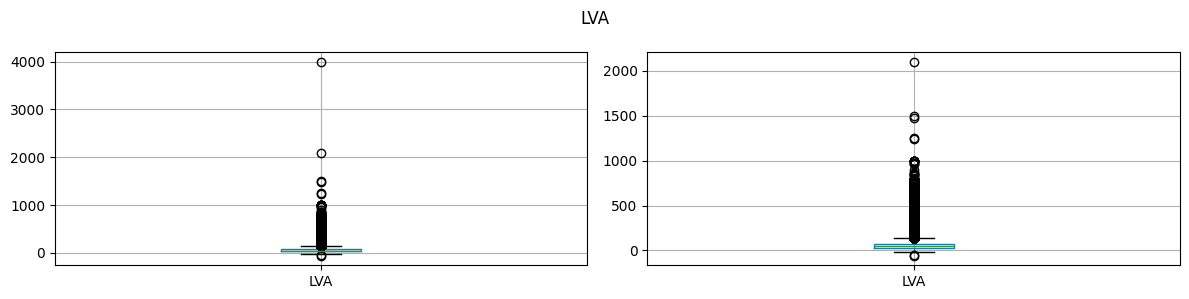

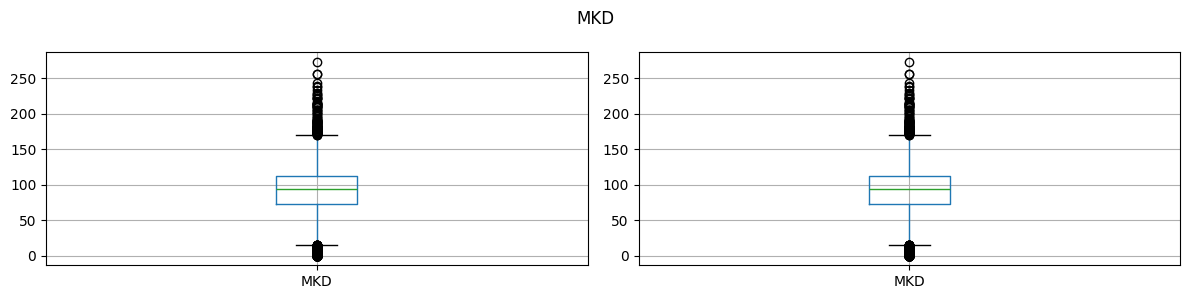

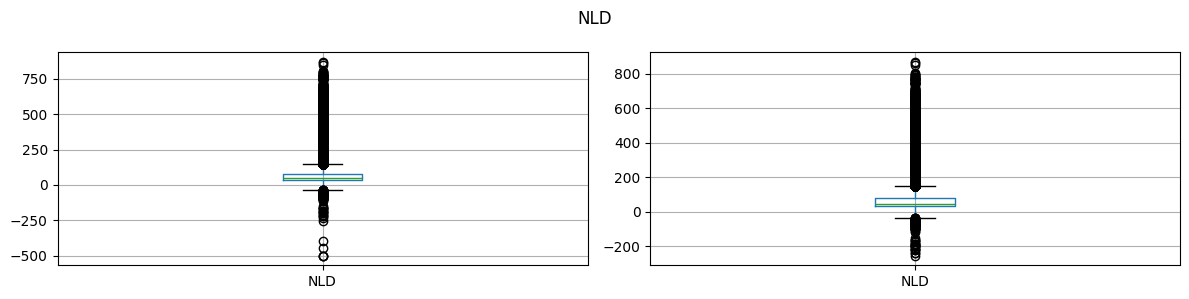

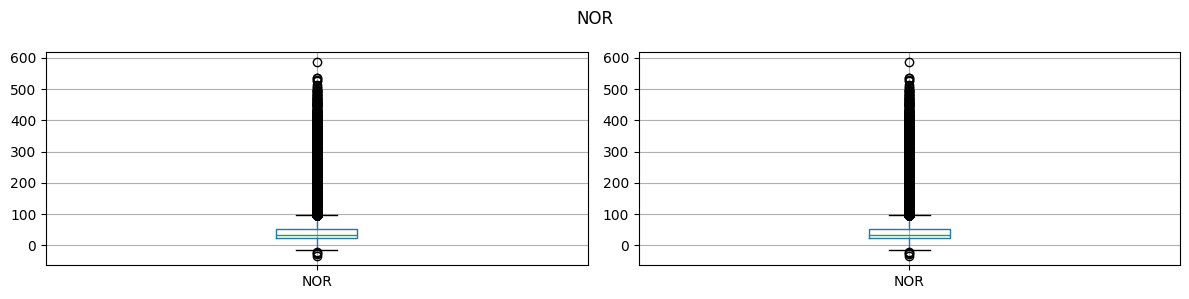

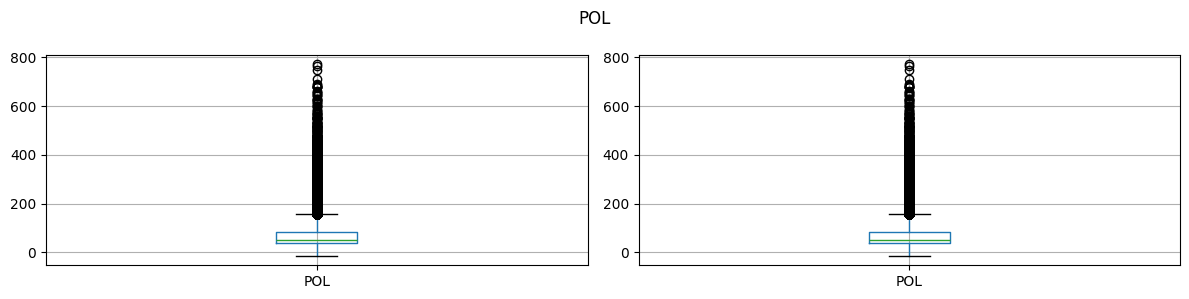

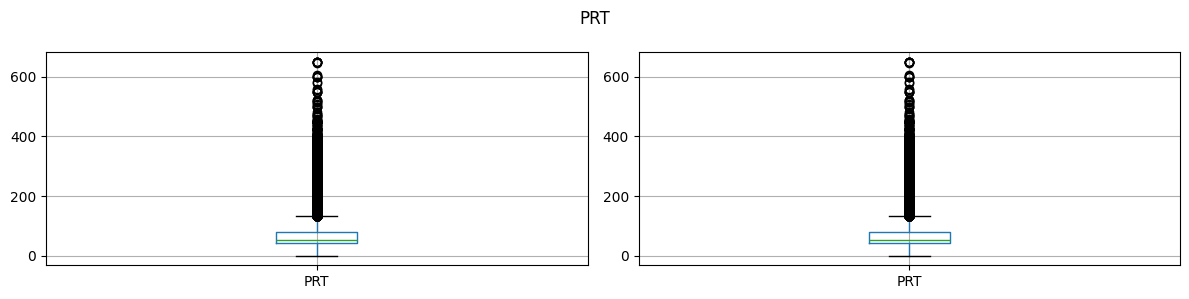

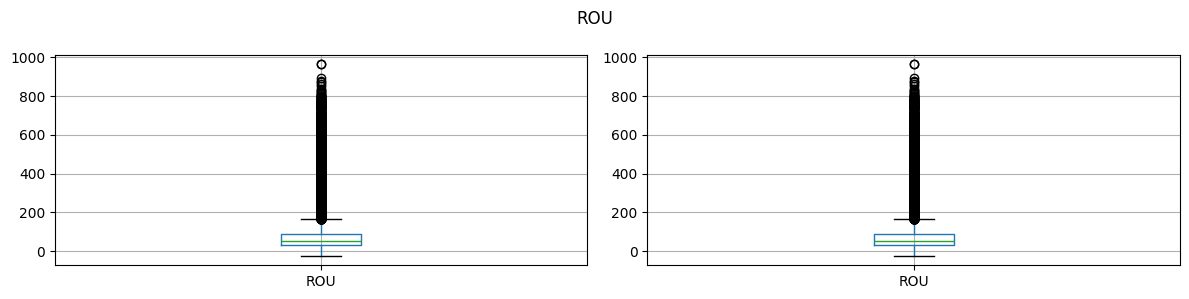

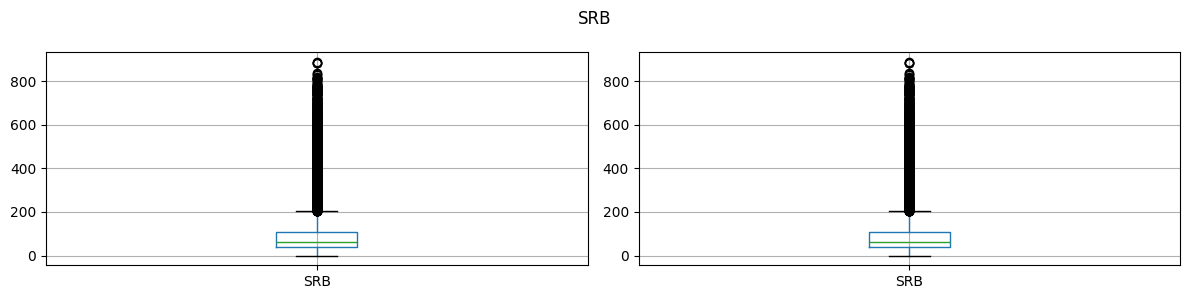

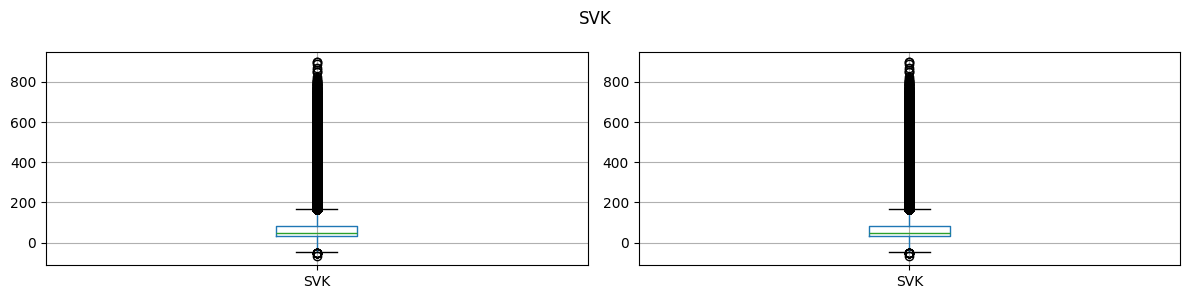

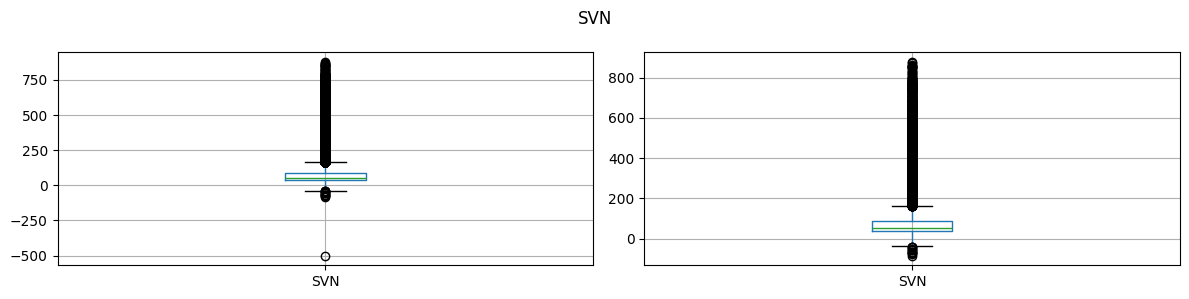

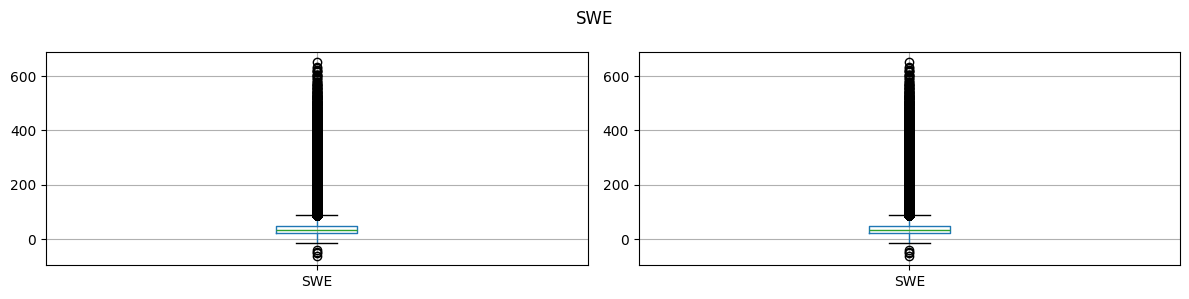

In [134]:
from matplotlib import pyplot as plt


for feature in df.select_dtypes(include='number').columns:  # ← add .columns
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))  # ← plt.subplots not df.subplots
    fig.suptitle(feature)
    
    df[[feature]].boxplot(ax=ax[0])
    df_clean[[feature]].boxplot(ax=ax[1])
    
    plt.tight_layout()
    plt.show()

In [ ]:
df.describe()

,AUT,BEL,BGR,CHE,CZE,DEU,DNK,ESP,EST,FIN,...,MKD,NLD,NOR,POL,PRT,ROU,SRB,SVK,SVN,SWE
count,81072.000000,81072.000000,65736.000000,81072.000000,81072.000000,81072.000000,81072.000000,81072.000000,81072.000000,81072.000000,...,8064.000000,81072.000000,81072.000000,81072.000000,81072.000000,81072.000000,64272.000000,81072.000000,81072.000000,81072.000000
mean,76.156180,77.288652,88.303996,83.664515,74.222359,70.909051,64.517878,71.218085,66.671852,55.681077,...,93.148641,75.161127,47.648969,70.025306,71.438546,81.358266,96.059328,77.892459,83.835990,47.138944
std,90.743384,84.600777,93.289934,91.894182,85.430286,86.577911,80.280396,55.660517,75.814145,67.791579,...,33.469345,82.735831,47.924336,54.053029,55.565892,90.799855,97.001500,90.375385,91.031576,52.745710
min,-500.000000,-500.000000,-1.800000,-142.880000,-68.540000,-500.000000,-288.140000,0.000000,-60.040000,-500.000000,...,0.000000,-500.000000,-32.710000,-13.810000,0.000000,-23.180000,0.000000,-65.000000,-500.000000,-60.040000
25%,30.200000,33.840000,34.560000,35.490000,30.837500,29.210000,25.870000,40.880000,29.900000,26.030000,...,73.487500,33.260000,23.900000,37.570000,41.000000,33.940000,41.670000,31.400000,36.970000,23.530000
50%,43.490000,48.265000,53.030000,50.055000,44.360000,41.920000,38.610000,53.550000,42.870000,37.970000,...,94.000000,45.480000,33.960000,50.460000,53.690000,50.210000,60.060000,46.000000,52.000000,33.740000
75%,81.020000,82.470000,104.460000,86.010000,80.512500,75.752500,67.070000,77.502500,71.190000,56.280000,...,112.150000,79.400000,52.560000,84.972500,77.930000,87.482500,107.595000,84.630000,88.092500,49.840000
max,908.900000,871.000000,3119.840000,871.610000,871.000000,1047.110000,871.000000,700.000000,4000.000000,1896.000000,...,273.600000,871.000000,587.630000,771.000000,651.000000,964.210000,889.520000,900.230000,879.290000,652.670000


In [ ]:
df_2023 = df[df.index.year == 2023].copy()
df_2023 = df_2023[['FRA', 'BEL']]
df_2023

,FRA,BEL
datetime_utc,,
2023-01-01 00:00:00+00:00,-0.10,-1.75
2023-01-01 01:00:00+00:00,-1.33,-1.46
2023-01-01 02:00:00+00:00,-4.08,-5.27
2023-01-01 03:00:00+00:00,-4.16,-4.41
2023-01-01 04:00:00+00:00,-3.58,-5.40
...,...,...
2023-12-31 19:00:00+00:00,16.43,19.65
2023-12-31 20:00:00+00:00,8.16,9.00
2023-12-31 21:00:00+00:00,10.68,10.68


In [ ]:
# # ── STEP 2: Short feature names ───────────────────────────────────────────────
# features_short = [
#     'mode_5',               # Most common price range (coarse) — where prices "sit" most often
#     'mode_10',              # Most common price range (fine) — more precise price clustering
#     'acf_timescale',        # How fast price autocorrelation decays — short=noisy, long=persistent
#     'acf_first_min',        # Lag of first autocorrelation minimum — typical price cycle length
#     'ami2',                 # Non-linear dependency between lagged values — hidden price patterns
#     'trev',                 # Time reversibility — is the price series asymmetric (spikes vs drops)?
#     'high_fluctuation',     # Proportion of large hour-to-hour changes — overall volatility
#     'stretch_high',         # Longest consecutive run above mean — sustained high price periods
#     'transition_matrix',    # Self-similarity across time — how repetitive is the price behavior?
#     'periodicity',          # Dominant cycle length — detects 24h or 168h seasonality
#     'embedding_dist',       # Structure in 2D phase space — complexity of price dynamics
#     'ami_timescale',        # Lag where mutual information first drops — non-linear memory length
#     'whiten_timescale',     # Timescale after removing linear structure — residual complexity
#     'outlier_timing_pos',   # Timing of positive price spikes — when do peaks tend to occur?
#     'outlier_timing_neg',   # Timing of negative price spikes — when do price crashes occur?
#     'low_freq_power',       # Energy in low frequencies — strength of slow trend component
#     'stretch_decreasing',   # Longest consecutive price decrease — bearish pressure duration
#     'entropy_pairs',        # Entropy of consecutive value pairs — randomness/predictability
#     'rs_range',             # Rescaled range scaling — Hurst-like long memory indicator
#     'dfa',                  # Detrended fluctuation analysis — long-range dependence strength
#     'centroid_freq',        # Center of mass of power spectrum — dominant frequency of prices
#     'forecast_error',       # Error of naive local mean forecast — how predictable is the series?
#      'mean',                # Average price level — overall costliness of electricity
#      'std'                  # Price variability — how much do prices fluctuate around the mean?
# ]

# # Your setup:
# window_size = 168  # catch22 sees 1 full week → captures weekly patterns ✅
# step        = 24   # one feature row per day  → ~365 rows for 2024 ✅

# # If you changed step=1:
# # → same feature quality, but ~8,700 rows (one per hour) and 29x slower

# # If you changed window_size=24:
# # → catch22 only sees 1 day → misses weekly seasonality ❌

In [ ]:
window_size = 168   # 1 week lookback, place 7 if daily values
step        = 24    # 1 day step → one row per day, place 1 if daily values
countries   = df_2023.columns.tolist()

In [ ]:
df_2023

,FRA,BEL
datetime_utc,,
2023-01-01 00:00:00+00:00,-0.10,-1.75
2023-01-01 01:00:00+00:00,-1.33,-1.46
2023-01-01 02:00:00+00:00,-4.08,-5.27
2023-01-01 03:00:00+00:00,-4.16,-4.41
2023-01-01 04:00:00+00:00,-3.58,-5.40
...,...,...
2023-12-31 19:00:00+00:00,16.43,19.65
2023-12-31 20:00:00+00:00,8.16,9.00
2023-12-31 21:00:00+00:00,10.68,10.68


In [ ]:
countries

['FRA', 'BEL']

In [ ]:
import pycatch22

# Get feature names once upfront from a test run
_test = pycatch22.catch22_all(df_2023[countries[0]].iloc[0:window_size].tolist(), catch24=True,short_names=True)
feature_names = _test['names']  # ← single source of truth

records = []

for i in range(window_size, len(df_2023), step):
    row = {'timestamp': df_2023.index[i]}

    for country in countries:
        window = df_2023[country].iloc[i - window_size:i]

        if window.isna().any():
            for feat in feature_names:                        # ← uses auto names
                row[f"{country}_{feat}"] = float('nan')
            continue

        result = pycatch22.catch22_all(window.tolist(), catch24=True, short_names=True)
        for feat_name, feat_val in zip(result['names'], result['values']):  # ← uses auto names
            row[f"{country}_{feat_name}"] = feat_val

    records.append(row)

features_df = pd.DataFrame(records).set_index('timestamp')

print(f"Feature names: {feature_names}")
print(f"Total columns: {features_df.shape[1]}")  # 29 × 24 = 696

Feature names: ['DN_HistogramMode_5', 'DN_HistogramMode_10', 'CO_f1ecac', 'CO_FirstMin_ac', 'CO_HistogramAMI_even_2_5', 'CO_trev_1_num', 'MD_hrv_classic_pnn40', 'SB_BinaryStats_mean_longstretch1', 'SB_TransitionMatrix_3ac_sumdiagcov', 'PD_PeriodicityWang_th0_01', 'CO_Embed2_Dist_tau_d_expfit_meandiff', 'IN_AutoMutualInfoStats_40_gaussian_fmmi', 'FC_LocalSimple_mean1_tauresrat', 'DN_OutlierInclude_p_001_mdrmd', 'DN_OutlierInclude_n_001_mdrmd', 'SP_Summaries_welch_rect_area_5_1', 'SB_BinaryStats_diff_longstretch0', 'SB_MotifThree_quantile_hh', 'SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1', 'SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1', 'SP_Summaries_welch_rect_centroid', 'FC_LocalSimple_mean3_stderr', 'DN_Mean', 'DN_Spread_Std']
Total columns: 48


In [ ]:
features_df.head(1)

,FRA_DN_HistogramMode_5,FRA_DN_HistogramMode_10,FRA_CO_f1ecac,FRA_CO_FirstMin_ac,FRA_CO_HistogramAMI_even_2_5,FRA_CO_trev_1_num,FRA_MD_hrv_classic_pnn40,FRA_SB_BinaryStats_mean_longstretch1,FRA_SB_TransitionMatrix_3ac_sumdiagcov,FRA_PD_PeriodicityWang_th0_01,...,BEL_DN_OutlierInclude_n_001_mdrmd,BEL_SP_Summaries_welch_rect_area_5_1,BEL_SB_BinaryStats_diff_longstretch0,BEL_SB_MotifThree_quantile_hh,BEL_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,BEL_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,BEL_SP_Summaries_welch_rect_centroid,BEL_FC_LocalSimple_mean3_stderr,BEL_DN_Mean,BEL_DN_Spread_Std
_date,,,,,,,,,,,,,,,,,,,,,
2023-01-08 00:00:00+00:00,0.624784,0.816304,8.117905,17,0.590428,0.010383,0.808383,42.0,0.046296,23,...,-0.785714,0.93138,12.0,1.550288,0.853659,0.731707,0.098175,0.449337,100.569286,53.517386


In [ ]:
# Step 1: create a temporary date column on the hourly df to use as merge key
df_2023['_date'] = df_2023.index.normalize()  # strips time → keeps date only

# Step 2: normalize features_df index too
features_df.index = features_df.index.normalize()
features_df.index.name = '_date'

# Step 3: merge on the date key
df_enriched = df_2023.merge(
    features_df,
    left_on='_date',
    right_index=True,
    how='left'
)

# Step 4: drop the helper column
df_enriched = df_enriched.drop(columns=['_date'])




In [ ]:
df_enriched.columns

Index(['FRA', 'BEL', 'FRA_DN_HistogramMode_5', 'FRA_DN_HistogramMode_10',
       'FRA_CO_f1ecac', 'FRA_CO_FirstMin_ac', 'FRA_CO_HistogramAMI_even_2_5',
       'FRA_CO_trev_1_num', 'FRA_MD_hrv_classic_pnn40',
       'FRA_SB_BinaryStats_mean_longstretch1',
       'FRA_SB_TransitionMatrix_3ac_sumdiagcov',
       'FRA_PD_PeriodicityWang_th0_01',
       'FRA_CO_Embed2_Dist_tau_d_expfit_meandiff',
       'FRA_IN_AutoMutualInfoStats_40_gaussian_fmmi',
       'FRA_FC_LocalSimple_mean1_tauresrat',
       'FRA_DN_OutlierInclude_p_001_mdrmd',
       'FRA_DN_OutlierInclude_n_001_mdrmd',
       'FRA_SP_Summaries_welch_rect_area_5_1',
       'FRA_SB_BinaryStats_diff_longstretch0', 'FRA_SB_MotifThree_quantile_hh',
       'FRA_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1',
       'FRA_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1',
       'FRA_SP_Summaries_welch_rect_centroid',
       'FRA_FC_LocalSimple_mean3_stderr', 'FRA_DN_Mean', 'FRA_DN_Spread_Std',
       'BEL_DN_HistogramMode_5', 'BEL_DN_HistogramMode_

In [ ]:
df_enriched.dropna()

,FRA,BEL,FRA_DN_HistogramMode_5,FRA_DN_HistogramMode_10,FRA_CO_f1ecac,FRA_CO_FirstMin_ac,FRA_CO_HistogramAMI_even_2_5,FRA_CO_trev_1_num,FRA_MD_hrv_classic_pnn40,FRA_SB_BinaryStats_mean_longstretch1,...,BEL_DN_OutlierInclude_n_001_mdrmd,BEL_SP_Summaries_welch_rect_area_5_1,BEL_SB_BinaryStats_diff_longstretch0,BEL_SB_MotifThree_quantile_hh,BEL_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,BEL_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,BEL_SP_Summaries_welch_rect_centroid,BEL_FC_LocalSimple_mean3_stderr,BEL_DN_Mean,BEL_DN_Spread_Std
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2023-01-08 00:00:00+00:00,10.44,8.79,0.624784,0.816304,8.117905,17.0,0.590428,0.010383,0.808383,42.0,...,-0.785714,0.931380,12.0,1.550288,0.853659,0.731707,0.098175,0.449337,100.569286,53.517386
2023-01-08 01:00:00+00:00,10.26,8.85,0.624784,0.816304,8.117905,17.0,0.590428,0.010383,0.808383,42.0,...,-0.785714,0.931380,12.0,1.550288,0.853659,0.731707,0.098175,0.449337,100.569286,53.517386
2023-01-08 02:00:00+00:00,4.16,3.14,0.624784,0.816304,8.117905,17.0,0.590428,0.010383,0.808383,42.0,...,-0.785714,0.931380,12.0,1.550288,0.853659,0.731707,0.098175,0.449337,100.569286,53.517386
2023-01-08 03:00:00+00:00,4.16,-1.45,0.624784,0.816304,8.117905,17.0,0.590428,0.010383,0.808383,42.0,...,-0.785714,0.931380,12.0,1.550288,0.853659,0.731707,0.098175,0.449337,100.569286,53.517386
2023-01-08 04:00:00+00:00,4.16,4.09,0.624784,0.816304,8.117905,17.0,0.590428,0.010383,0.808383,42.0,...,-0.785714,0.931380,12.0,1.550288,0.853659,0.731707,0.098175,0.449337,100.569286,53.517386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 18:00:00+00:00,17.75,20.26,-0.974687,-0.797231,9.798349,18.0,0.613832,-0.003932,0.730539,32.0,...,-0.553571,0.939015,11.0,1.537123,0.829268,0.756098,0.073631,0.469163,24.279821,27.683140
2023-12-31 19:00:00+00:00,16.43,19.65,-0.974687,-0.797231,9.798349,18.0,0.613832,-0.003932,0.730539,32.0,...,-0.553571,0.939015,11.0,1.537123,0.829268,0.756098,0.073631,0.469163,24.279821,27.683140
2023-12-31 20:00:00+00:00,8.16,9.00,-0.974687,-0.797231,9.798349,18.0,0.613832,-0.003932,0.730539,32.0,...,-0.553571,0.939015,11.0,1.537123,0.829268,0.756098,0.073631,0.469163,24.279821,27.683140


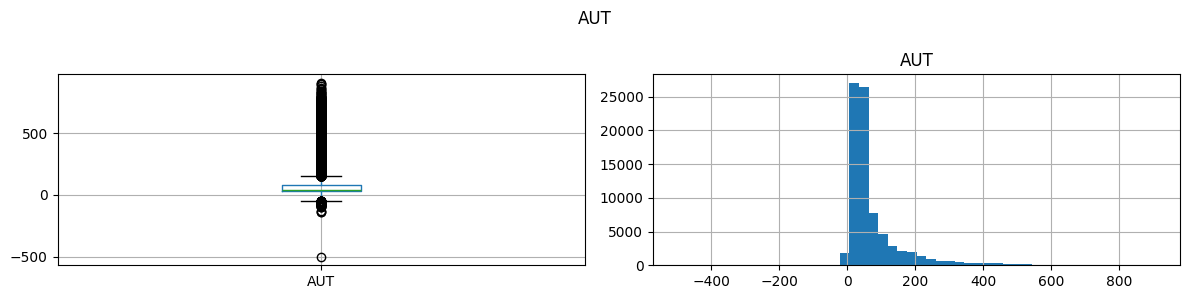

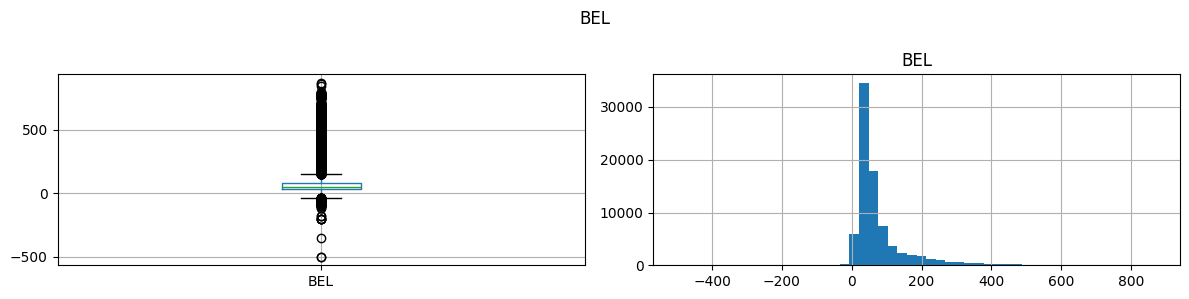

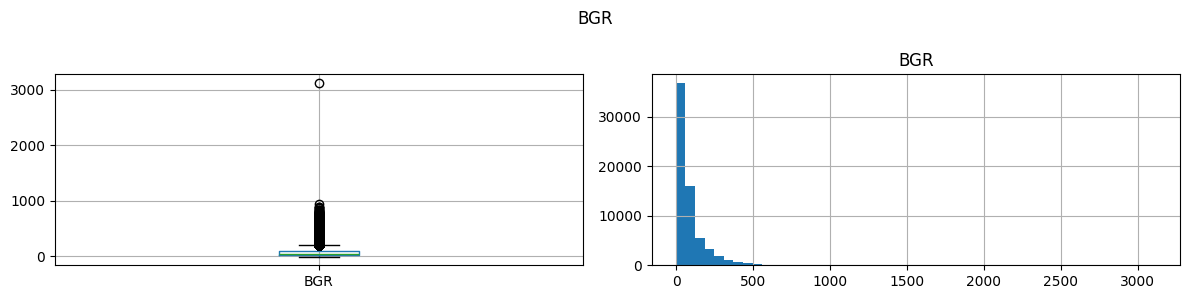

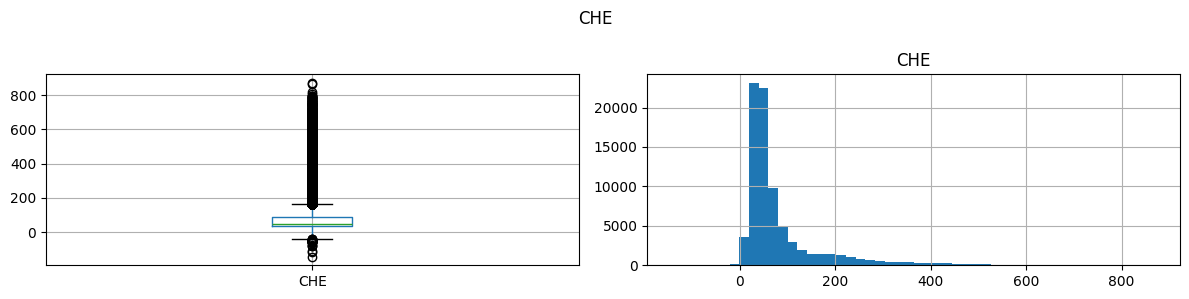

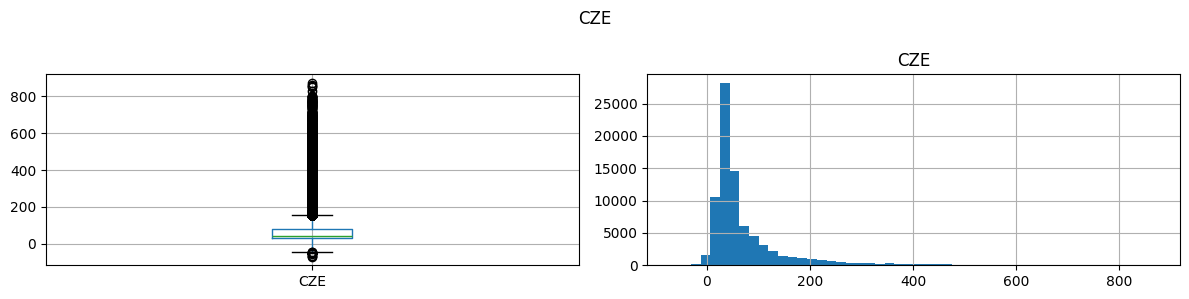

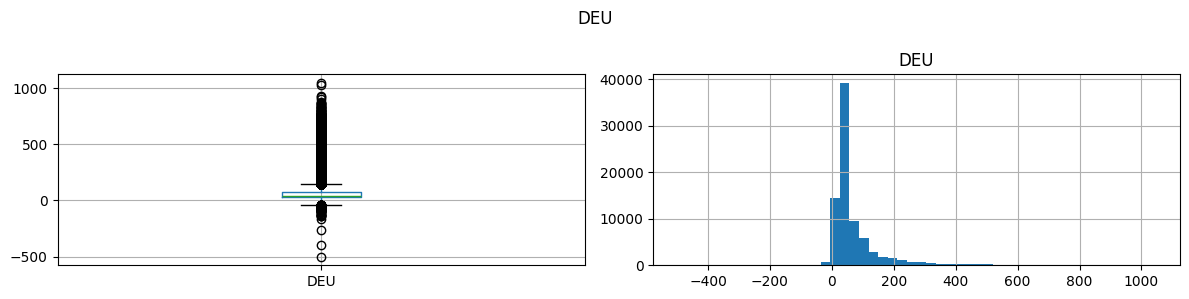

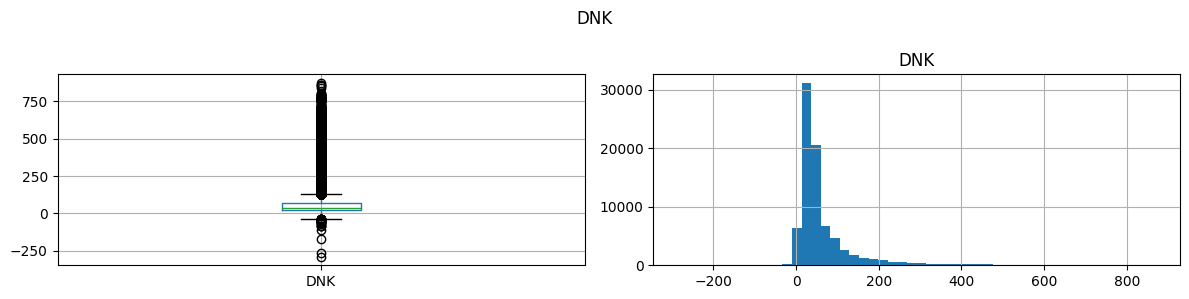

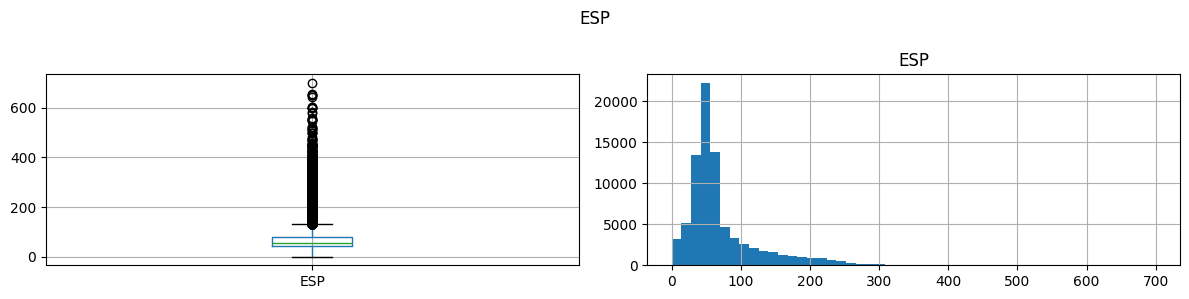

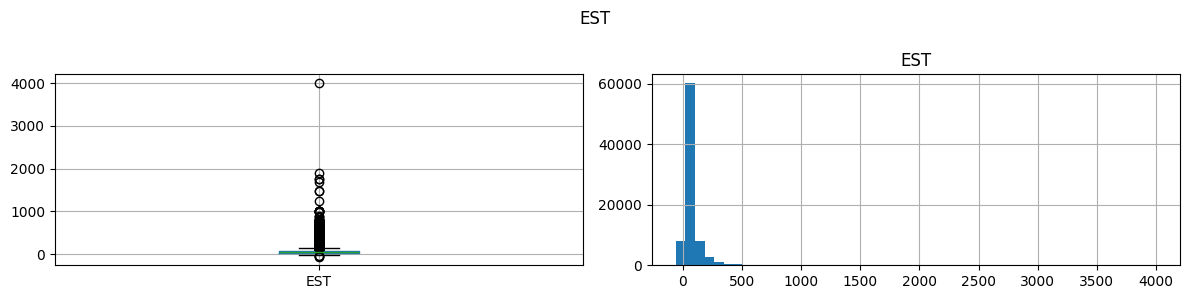

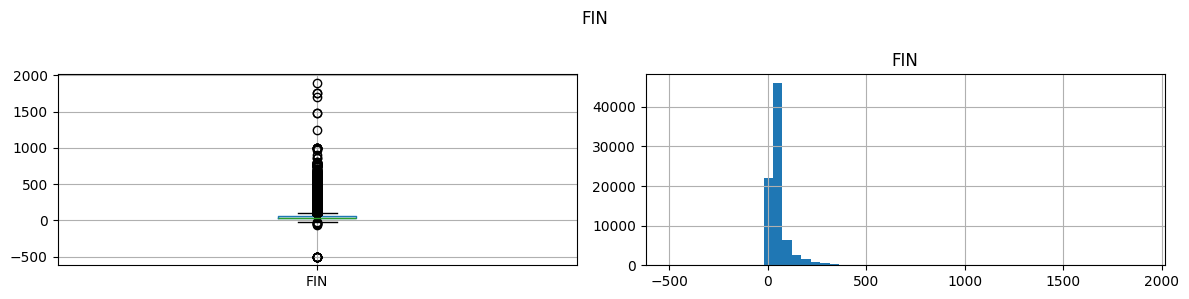

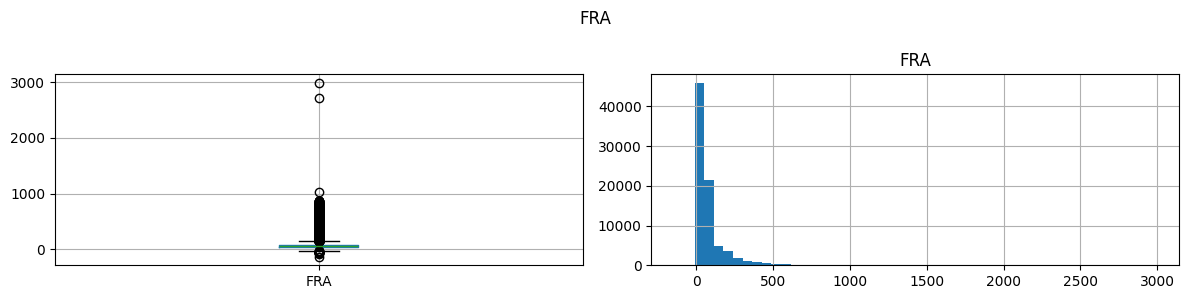

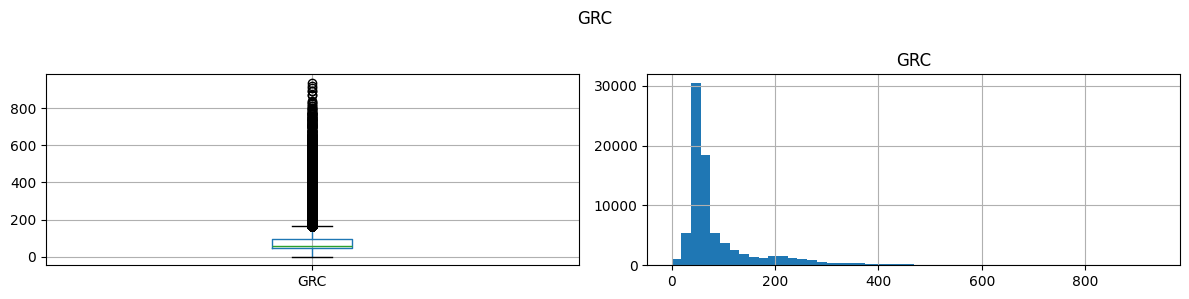

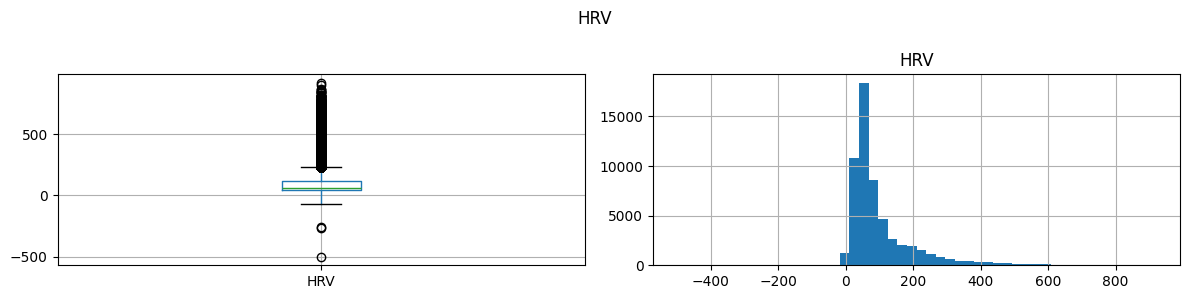

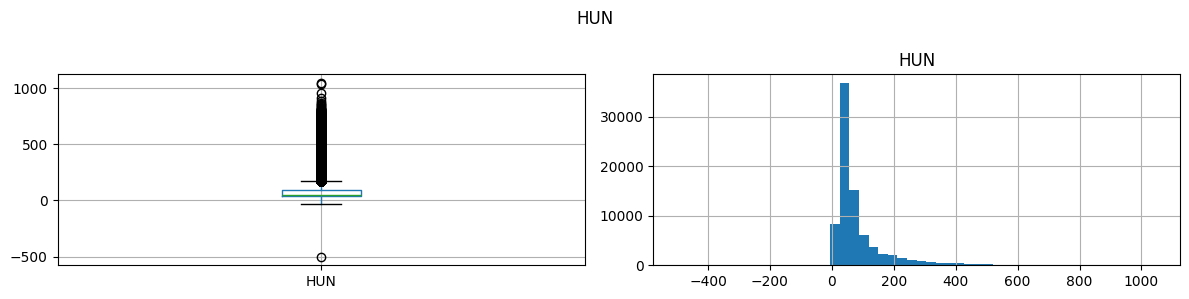

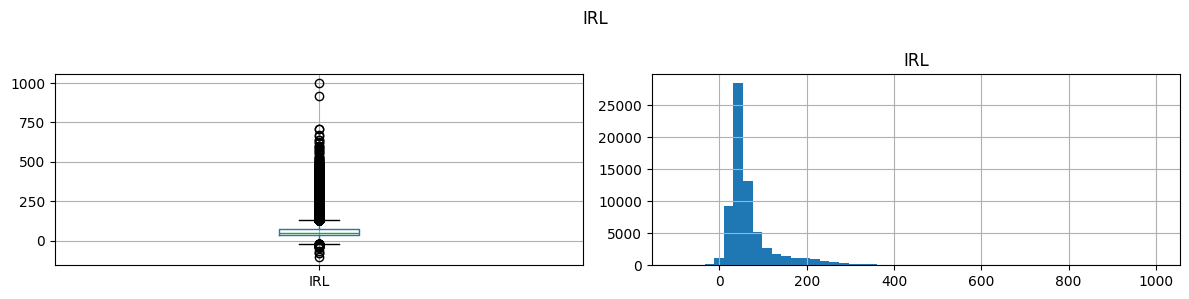

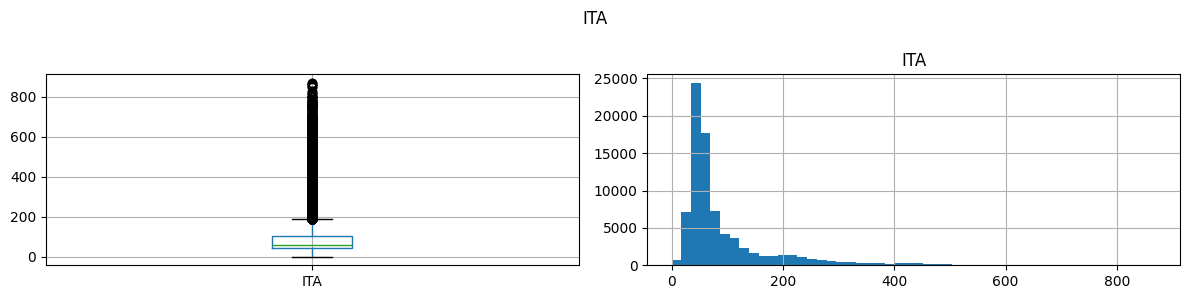

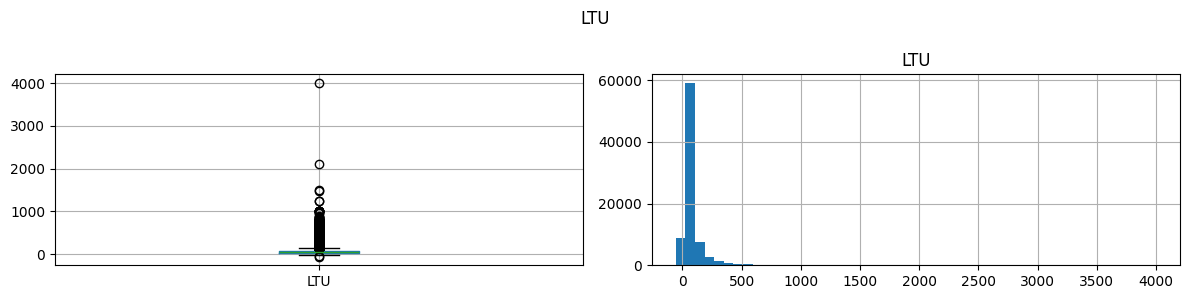

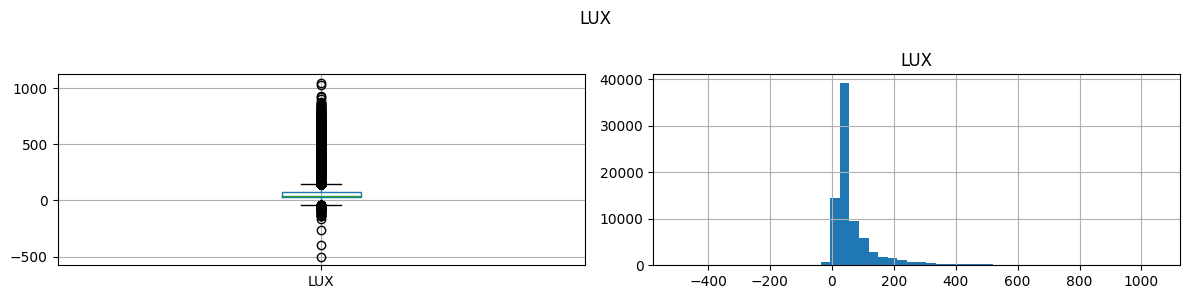

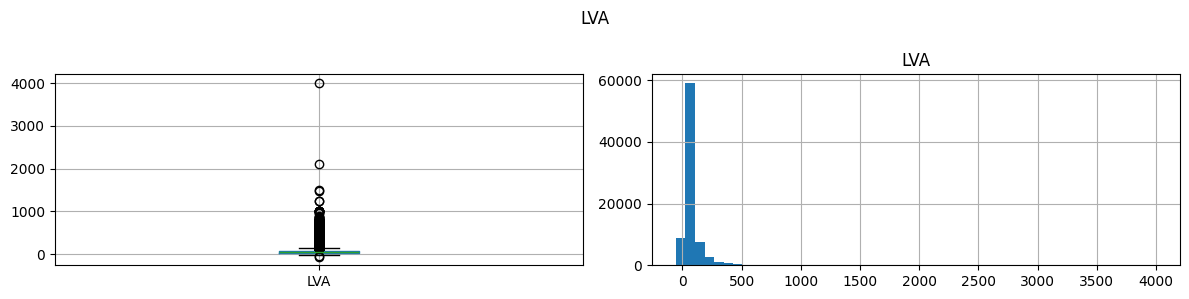

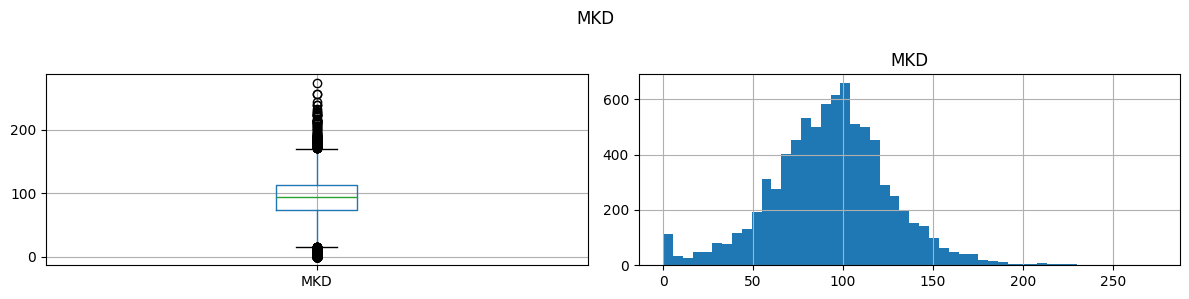

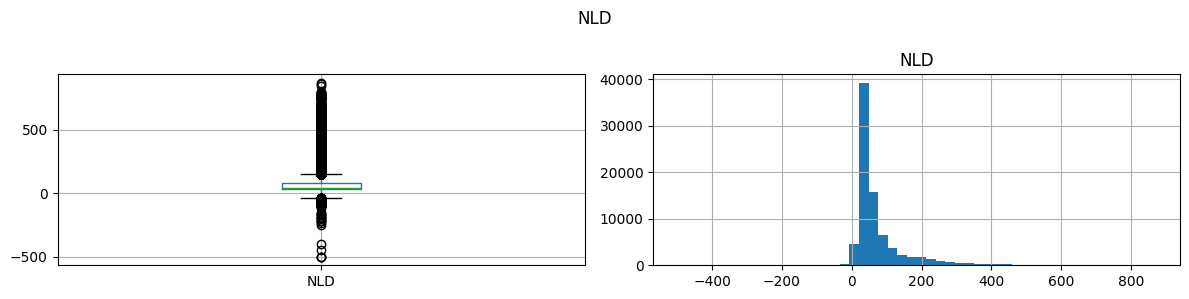

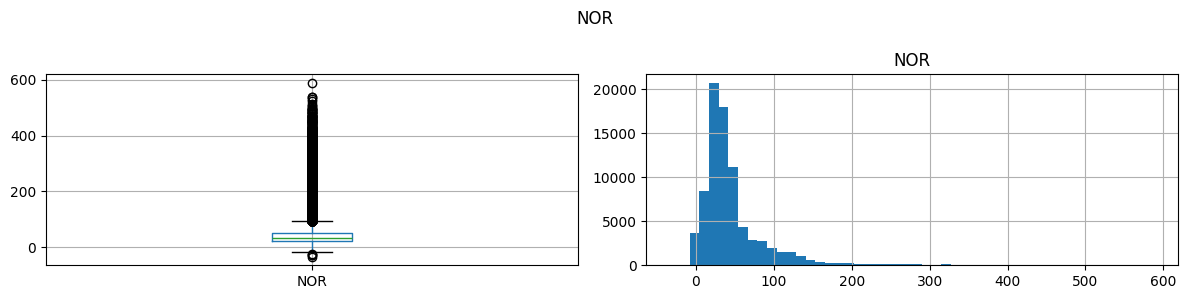

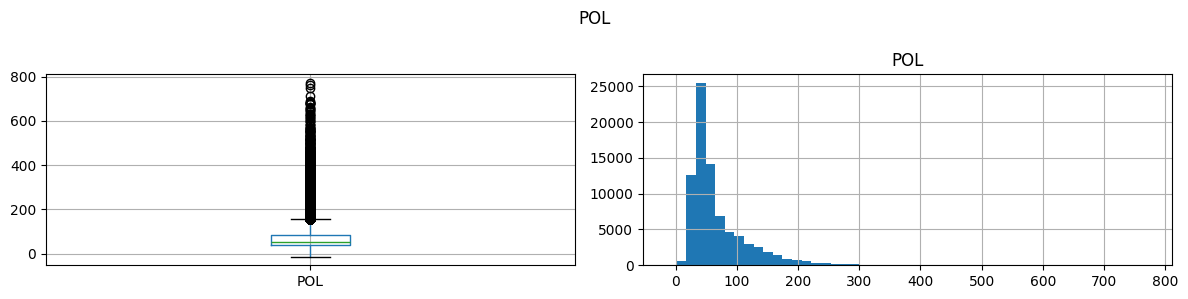

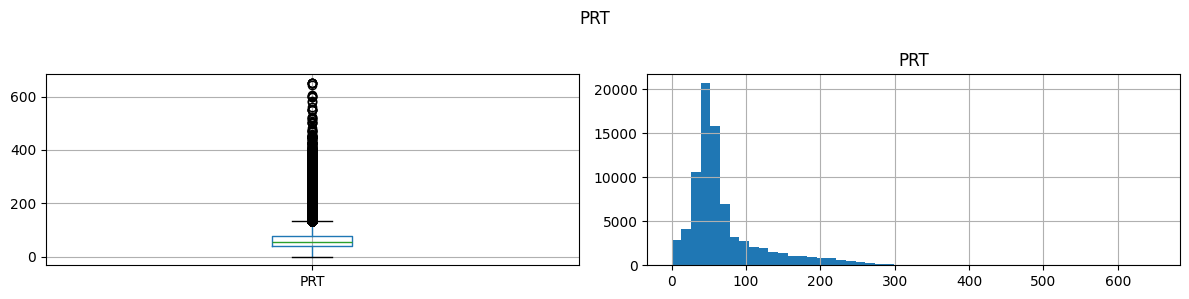

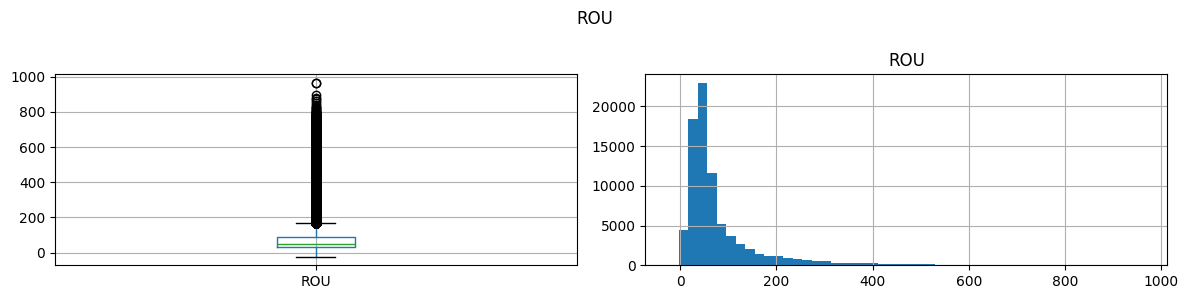

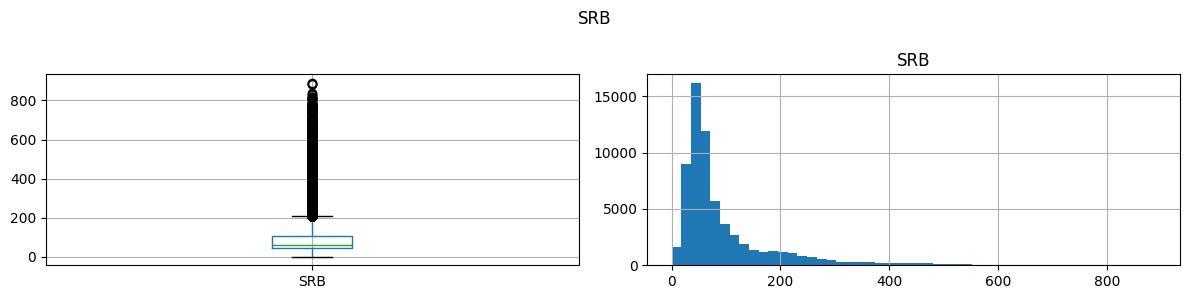

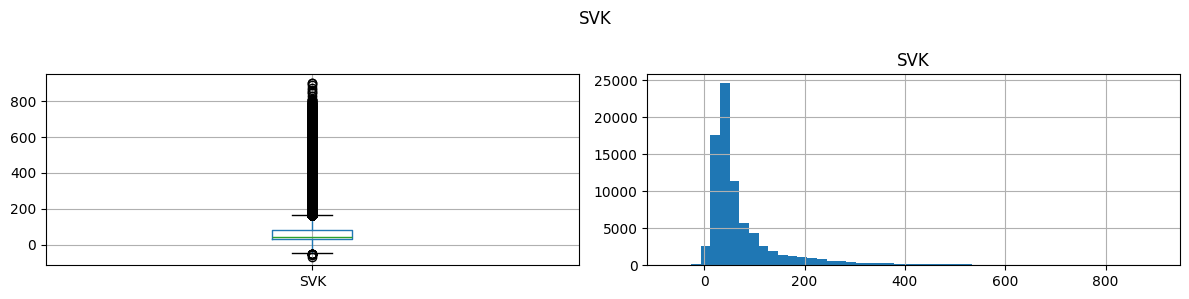

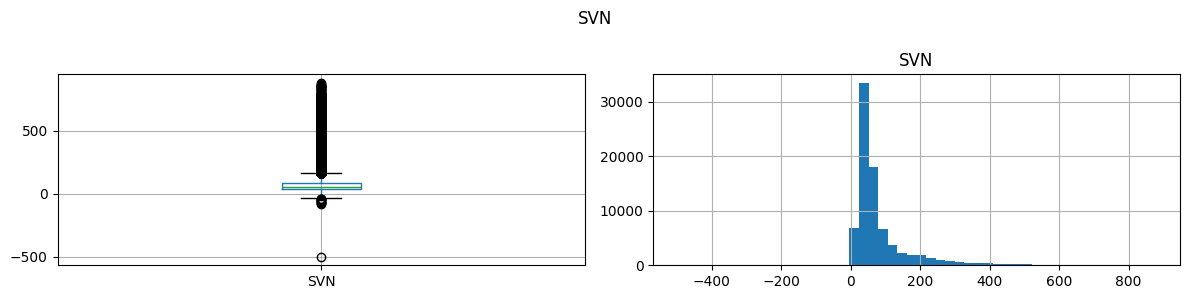

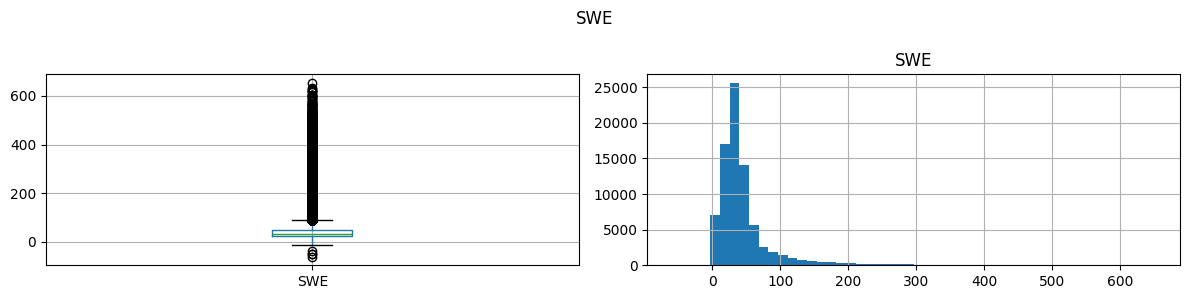